In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav.head())

   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


In [3]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns = nav.dropna(subset=["daily_return"])

daily_returns.to_csv(
    "../reports/performance/returns_computed.csv",
    index=False
)

daily_returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


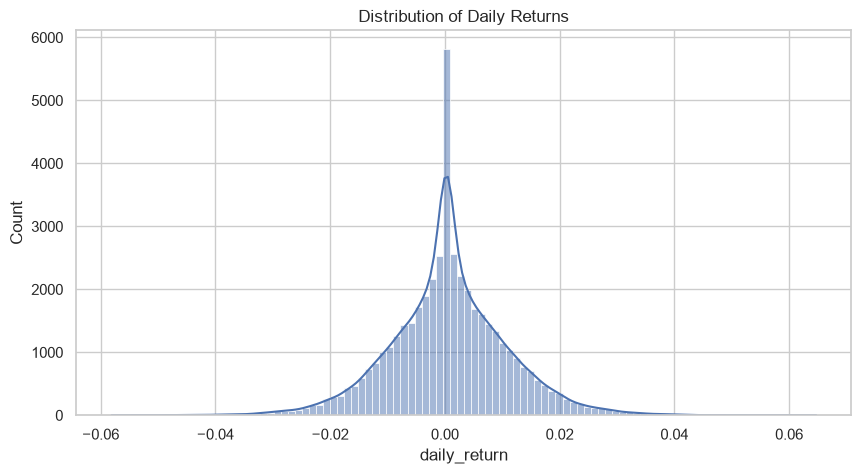

In [4]:
plt.figure(figsize=(10,5))

sns.histplot(
    daily_returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.savefig("../reports/performance/daily_return_distribution.png")

plt.show()

In [5]:
years = [1,3,5]

cagr_table = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    latest = df.iloc[-1]

    row = {"amfi_code":code}

    for yr in years:

        days = 252*yr

        if len(df)>=days:

            start = df.iloc[-days]["nav"]

            end = latest["nav"]

            cagr = (end/start)**(1/yr)-1

            row[f"{yr}yr_CAGR"]=cagr

        else:

            row[f"{yr}yr_CAGR"]=np.nan

    cagr_table.append(row)

cagr = pd.DataFrame(cagr_table)

cagr.to_csv(
    "../reports/performance/cagr_report.csv",
    index=False
)

cagr.head()

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [6]:
RF = 0.065

sharpe=[]

for code,df in daily_returns.groupby("amfi_code"):

    mean=df["daily_return"].mean()*252

    std=df["daily_return"].std()*np.sqrt(252)

    value=(mean-RF)/std

    sharpe.append([code,value])

sharpe=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)

sharpe=sharpe.sort_values(
    "Sharpe",
    ascending=False
)

sharpe.to_csv(
    "../reports/performance/sharpe_values.csv",
    index=False
)

sharpe.head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
sortino=[]

for code,df in daily_returns.groupby("amfi_code"):

    downside=df[df["daily_return"]<0]["daily_return"]

    downside_std=downside.std()*np.sqrt(252)

    annual=df["daily_return"].mean()*252

    value=(annual-RF)/downside_std

    sortino.append([code,value])

sortino=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

sortino.to_csv(
    "../reports/performance/sortino_values.csv",
    index=False
)

sortino.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [9]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [11]:
# Pivot benchmark data
benchmark_pivot = benchmark.pivot_table(
    index="date",
    columns="index_name",
    values="close_value"
)

benchmark_returns = benchmark_pivot.pct_change().dropna()

benchmark_returns.head()

index_name,BSE_SMALLCAP,CRISIL_GILT,CRISIL_LIQUID,NIFTY100,NIFTY50,NIFTY500,NIFTY_MIDCAP150
date,,,,,,,
2022-01-04,0.019783,0.001516,0.000044,-0.013540,0.011253,-0.006332,0.023909
2022-01-05,0.008620,0.001541,0.000307,0.004003,0.008220,0.014747,-0.009562
2022-01-06,0.002332,-0.000749,0.000263,-0.002935,0.002437,-0.000685,-0.007253
2022-01-07,-0.038726,-0.000055,0.000819,0.006150,-0.006676,0.006300,0.001611
2022-01-10,0.006049,0.001568,0.000026,-0.008351,0.020592,-0.007753,0.004197


In [12]:
# Pivot NAV data
fund_nav = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

fund_returns = fund_nav.pct_change().dropna()

fund_returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-10,-0.008639,0.006791,0.006277,0.011548,0.001251,0.000690,-0.001202,-0.000722,-0.011593,0.006360,...,-0.002583,0.000853,0.003057,-0.019536,0.024234,-0.011127,0.009372,0.001601,0.003650,0.001356


In [13]:
alpha_beta = []

benchmark_series = benchmark_returns["NIFTY100"]

for fund in fund_returns.columns:

    temp = pd.concat(
        [fund_returns[fund], benchmark_series],
        axis=1
    ).dropna()

    temp.columns = ["fund", "benchmark"]

    slope, intercept, r, p, stderr = linregress(
        temp["benchmark"],
        temp["fund"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append([
        fund,
        alpha,
        beta
    ])

alpha_beta = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta.to_csv(
    "../reports/performance/alpha_beta.csv",
    index=False
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [14]:
drawdown = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    running_max = df["nav"].cummax()

    drawdown_series = (df["nav"] / running_max) - 1

    drawdown.append({
        "amfi_code": code,
        "Maximum_Drawdown": drawdown_series.min()
    })

drawdown = pd.DataFrame(drawdown)

drawdown.to_csv(
    "../reports/performance/max_drawdown.csv",
    index=False
)

drawdown.head()

,amfi_code,Maximum_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [15]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [16]:
score = (
    cagr
    .merge(sharpe, on="amfi_code")
    .merge(sortino, on="amfi_code")
    .merge(alpha_beta, on="amfi_code")
    .merge(drawdown, on="amfi_code")
    .merge(
        fund_master[
            [
                "amfi_code",
                "scheme_name",
                "expense_ratio_pct"
            ]
        ],
        on="amfi_code"
    )
)

score.head()

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR,Sharpe,Sortino,Alpha,Beta,Maximum_Drawdown,scheme_name,expense_ratio_pct
0,100016,-0.033055,-0.000316,NaN,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100025,0.025018,0.046143,NaN,-0.567095,-0.941821,0.042818,0.001158,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,0.56
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,1.60
4,101207,-0.242421,-0.026965,NaN,0.162661,0.276644,0.108971,-0.065289,-0.354469,ABSL Small Cap Fund - Regular - Growth,1.53


In [17]:
score["ReturnRank"] = score["3yr_CAGR"].rank(ascending=False)

score["SharpeRank"] = score["Sharpe"].rank(ascending=False)

score["AlphaRank"] = score["Alpha"].rank(ascending=False)

score["ExpenseRank"] = score["expense_ratio_pct"].rank()

score["DrawdownRank"] = score["Maximum_Drawdown"].rank(
    ascending=False
)

score.head()

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR,Sharpe,Sortino,Alpha,Beta,Maximum_Drawdown,scheme_name,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank
0,100016,-0.033055,-0.000316,NaN,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,1.55,36.0,35.0,39.0,32.0,34.0
1,100025,0.025018,0.046143,NaN,-0.567095,-0.941821,0.042818,0.001158,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,0.56,33.0,39.0,38.0,2.0,4.0
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,2.0,7.0,6.0,17.0,20.0
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,-0.112916,ABSL Frontline Equity Fund - Regular - Growth,1.60,3.0,9.0,12.0,36.5,9.0
4,101207,-0.242421,-0.026965,NaN,0.162661,0.276644,0.108971,-0.065289,-0.354469,ABSL Small Cap Fund - Regular - Growth,1.53,39.0,28.0,27.0,28.5,38.0


In [18]:
score["FundScore"] = (

30 * score["ReturnRank"]

+ 25 * score["SharpeRank"]

+ 20 * score["AlphaRank"]

+ 15 * score["ExpenseRank"]

+ 10 * score["DrawdownRank"]

)

score["FundScore"] = (

100 *

(score["FundScore"] - score["FundScore"].min())

/

(score["FundScore"].max() - score["FundScore"].min())

)

score = score.sort_values(
    "FundScore",
    ascending=False
)

score.to_csv(
    "../reports/performance/fund_scorecard.csv",
    index=False
)

score.head(10)

,amfi_code,1yr_CAGR,3yr_CAGR,5yr_CAGR,Sharpe,Sortino,Alpha,Beta,Maximum_Drawdown,scheme_name,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,FundScore
7,102886,-0.132261,-0.018322,NaN,-0.205832,-0.347222,0.028969,-0.042125,-0.280011,UTI Mid Cap Fund - Regular - Growth,1.51,38.0,36.0,40.0,24.5,35.0,100.000000
0,100016,-0.033055,-0.000316,NaN,-0.201517,-0.351047,0.037476,-0.058268,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth,1.55,36.0,35.0,39.0,32.0,34.0,99.912204
17,119095,-0.454229,-0.110655,NaN,-0.075974,-0.128186,0.048016,-0.066951,-0.516778,Axis Small Cap Fund - Regular - Growth,1.38,40.0,33.0,37.0,17.0,39.0,94.820018
4,101207,-0.242421,-0.026965,NaN,0.162661,0.276644,0.108971,-0.065289,-0.354469,ABSL Small Cap Fund - Regular - Growth,1.53,39.0,28.0,27.0,28.5,38.0,88.059701
14,119092,0.034030,0.005560,NaN,0.030785,0.052574,0.068995,0.009731,-0.144016,Axis Bluechip Fund - Regular - Growth,1.64,35.0,31.0,30.0,39.5,15.0,86.303775
22,119599,0.119080,-0.006866,NaN,-0.057187,-0.094387,0.048824,0.062002,-0.525742,SBI Small Cap Fund - Direct Plan - Growth,0.72,37.0,32.0,36.0,5.5,40.0,84.372256
29,120842,0.186054,0.100406,NaN,0.076000,0.124693,0.078044,0.018057,-0.240035,Kotak Emerging Equity Fund - Regular - Growth,1.56,27.0,30.0,29.0,33.0,33.0,79.192274
1,100025,0.025018,0.046143,NaN,-0.567095,-0.941821,0.042818,0.001158,-0.043083,HDFC Short Term Debt Fund - Regular - Growth,0.56,33.0,39.0,38.0,2.0,4.0,73.222125
5,101208,0.068543,0.060762,NaN,-0.815567,-1.681038,0.060861,0.000267,-0.001622,ABSL Liquid Fund - Regular - Growth,0.79,31.0,40.0,33.0,11.0,3.0,72.870939
18,119120,0.057231,0.056060,NaN,-0.226575,-0.376767,0.056209,-0.006414,-0.043287,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,32.0,37.0,34.0,9.0,5.0,71.641791


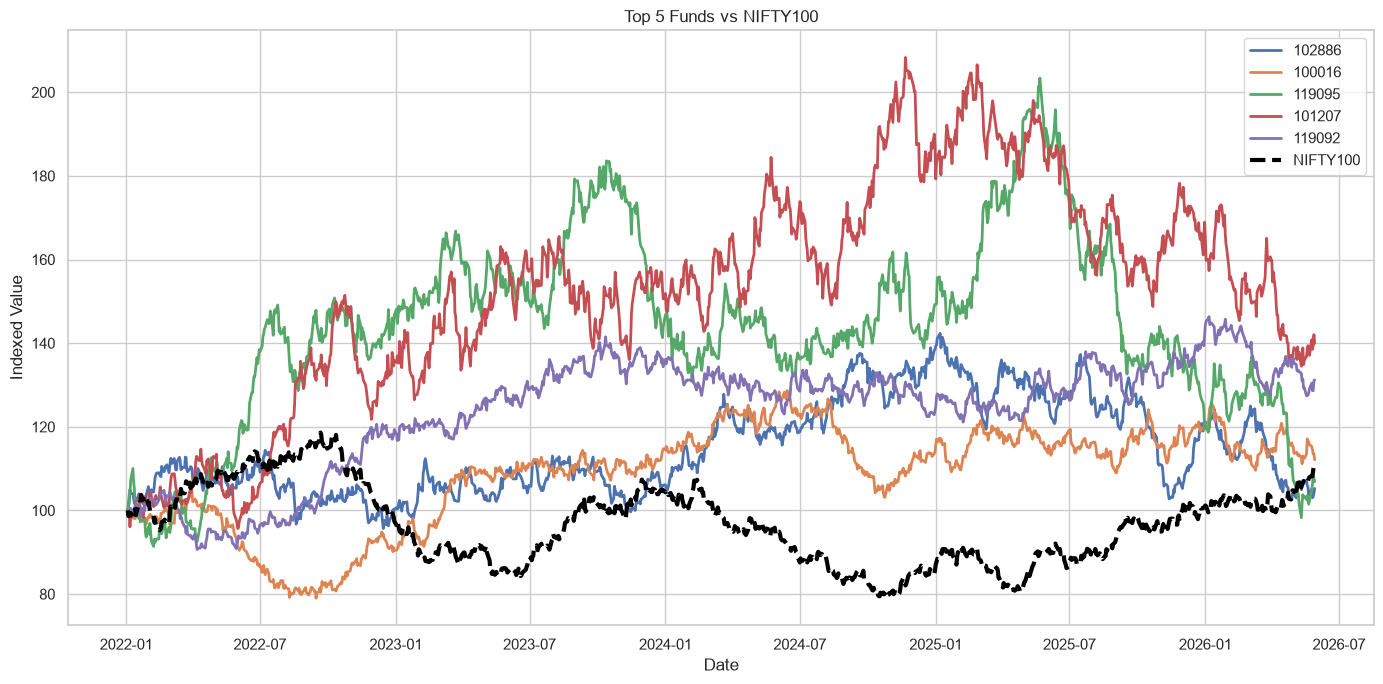

In [19]:
top5 = score.head(5)["amfi_code"]

plt.figure(figsize=(14,7))

for code in top5:

    temp = fund_nav[code]

    temp = temp / temp.iloc[0] * 100

    plt.plot(
        temp.index,
        temp.values,
        linewidth=2,
        label=str(code)
    )

benchmark_plot = benchmark_pivot["NIFTY100"]

benchmark_plot = benchmark_plot / benchmark_plot.iloc[0] * 100

plt.plot(
    benchmark_plot.index,
    benchmark_plot.values,
    linewidth=3,
    linestyle="--",
    color="black",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("Indexed Value")
plt.legend()

plt.tight_layout()

plt.savefig("../reports/performance/benchmark_chart.png")

plt.show()

In [20]:
tracking = []

benchmark_daily = benchmark_returns["NIFTY100"]

for code in top5:

    temp = pd.concat(
        [
            fund_returns[code],
            benchmark_daily
        ],
        axis=1
    ).dropna()

    temp.columns = [
        "fund",
        "benchmark"
    ]

    tracking_error = np.std(
        temp["fund"] - temp["benchmark"]
    ) * np.sqrt(252)

    tracking.append([
        code,
        tracking_error
    ])

tracking = pd.DataFrame(
    tracking,
    columns=[
        "amfi_code",
        "Tracking_Error"
    ]
)

tracking

,amfi_code,Tracking_Error
0,102886,0.225510
1,100016,0.199197
2,119095,0.285657
3,101207,0.291990
4,119092,0.188999


# Day 4 Summary

## Completed Analysis

- Daily Return Calculation
- CAGR (1 Year, 3 Year, 5 Year)
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown
- Composite Fund Scorecard
- Benchmark Comparison
- Tracking Error

## Deliverables

- returns_computed.csv
- cagr_report.csv
- sharpe_values.csv
- sortino_values.csv
- alpha_beta.csv
- max_drawdown.csv
- fund_scorecard.csv
- benchmark_chart.png